# PX4 Phase 1 Rate Dynamics PINN Training v4 Alt/Yaw Physics

Train the multi-run nominal local dynamics model with stronger altitude and yaw-informed constraints.

Model contract:

```text
x_t, u_t, prev_u_t, du_t, dt_s -> dx_t
```

Compared with v3:

- keeps nominal-pool validation and `N11_mixed_sequence` hard test
- strengthens altitude kinematics loss
- separates yaw kinematics from roll/pitch Euler loss
- uses wrap-aware yaw residual so heading near +/-180 deg is handled correctly
- adds small direct emphasis on altitude/yaw data targets through target-weighted SmoothL1


In [1]:
# Colab setup
from pathlib import Path
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


Mounted at /content/drive
device: cuda
torch: 2.10.0+cu128


In [2]:
# Dataset path
# Option A: set this manually after copying the processed folder into Drive.
DATASET_DIR = ''  # e.g. '/content/drive/MyDrive/PX4_Datasets/px4_phase1_rate_dynamics_dataset_v2_multirun_20260506_190000'

# Option B: automatically search common locations.
def find_latest_dataset_dir():
    patterns = [
        '/content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
        '/content/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
        './px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
    ]
    matches = []
    import glob
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    matches = sorted(set(matches))
    matches = [Path(m) for m in matches if (Path(m) / 'train.csv').exists()]
    if not matches:
        raise FileNotFoundError(
            'No processed dataset found. Set DATASET_DIR to the folder containing train.csv/val.csv/test.csv.'
        )
    return matches[-1]

DATASET_PATH = Path(DATASET_DIR) if DATASET_DIR else find_latest_dataset_dir()
print('DATASET_PATH:', DATASET_PATH)
print('files:', sorted([p.name for p in DATASET_PATH.iterdir()])[:20])


DATASET_PATH: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024
files: ['all_samples.csv', 'dataset_summary.csv', 'filter_report.csv', 'metadata.json', 'source_summary.csv', 'test.csv', 'train.csv', 'val.csv']


In [3]:
# Load processed CSVs and rebuild a more nominal validation split
base_train = pd.read_csv(DATASET_PATH / 'train.csv')
base_val = pd.read_csv(DATASET_PATH / 'val.csv')
base_test = pd.read_csv(DATASET_PATH / 'test.csv')
all_df = pd.read_csv(DATASET_PATH / 'all_samples.csv') if (DATASET_PATH / 'all_samples.csv').exists() else pd.concat([base_train, base_val, base_test], ignore_index=True)

metadata = {}
if (DATASET_PATH / 'metadata.json').exists():
    metadata = json.loads((DATASET_PATH / 'metadata.json').read_text())

state_cols = metadata.get('state_cols') or [c.removeprefix('dx_') for c in all_df.columns if c.startswith('dx_')]
action_cols = metadata.get('action_cols') or [c.removeprefix('u_') for c in all_df.columns if c.startswith('u_')]

feature_cols = (
    [f'x_{c}' for c in state_cols]
    + [f'u_{c}' for c in action_cols]
    + [f'prev_u_{c}' for c in action_cols]
    + [f'du_{c}' for c in action_cols]
    + ['dt_s']
)
target_cols = [f'dx_{c}' for c in state_cols]
next_cols = [f'x_next_{c}' for c in state_cols]

missing = [c for c in feature_cols + target_cols if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

# v2 used N10 as a full validation scenario, which can make early stopping depend on
# one unusual coupled case. For v3, keep a hard mixed sequence test set, and sample
# validation from the broader nominal pool. This makes validation more representative
# of ordinary training behavior while test still checks harder rollout generalization.
RESPLIT_FOR_NOMINAL_VALIDATION = True
TEST_SCENARIOS = ['N11_mixed_sequence']
VAL_FRACTION = 0.15

if RESPLIT_FOR_NOMINAL_VALIDATION:
    rng = np.random.default_rng(SEED)
    test_mask = all_df['scenario'].isin(TEST_SCENARIOS) if 'scenario' in all_df.columns else pd.Series(False, index=all_df.index)
    test_df = all_df[test_mask].copy()
    pool_df = all_df[~test_mask].copy()
    val_indices = []
    group_cols = [c for c in ['source_run', 'scenario'] if c in pool_df.columns]
    if group_cols:
        for _, group in pool_df.groupby(group_cols, sort=False):
            n_val = max(1, int(round(len(group) * VAL_FRACTION))) if len(group) >= 20 else 0
            if n_val:
                val_indices.extend(rng.choice(group.index.to_numpy(), size=n_val, replace=False).tolist())
    else:
        n_val = int(round(len(pool_df) * VAL_FRACTION))
        val_indices = rng.choice(pool_df.index.to_numpy(), size=n_val, replace=False).tolist()
    val_df = pool_df.loc[sorted(val_indices)].copy()
    train_df = pool_df.drop(index=val_df.index).copy()
else:
    train_df, val_df, test_df = base_train, base_val, base_test

print('train/val/test rows:', len(train_df), len(val_df), len(test_df))
print('state_cols:', state_cols)
print('action_cols:', action_cols)
print('n_features:', len(feature_cols), 'n_targets:', len(target_cols))

display(pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
}))

if 'scenario' in train_df.columns:
    split_view = pd.concat([
        train_df.assign(split='train'),
        val_df.assign(split='val'),
        test_df.assign(split='test'),
    ])
    display(split_view.groupby(['split', 'scenario']).size().to_frame('rows').reset_index())


train/val/test rows: 5969 1055 899
state_cols: ['relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action_cols: ['ref_roll_rate_rad_s', 'ref_pitch_rate_rad_s', 'ref_yaw_rate_rad_s', 'ref_thrust']
n_features: 23 n_targets: 10


,split,rows
0,train,5969
1,val,1055
2,test,899


,split,scenario,rows
0,test,N11_mixed_sequence,899
1,train,N00_hover_hold_0p5192,509
2,train,N01_pitch_rate_doublet_5dps,323
3,train,N02_pitch_rate_doublet_10dps,594
4,train,N03_roll_rate_doublet_5dps,303
5,train,N04_roll_rate_doublet_10dps,592
6,train,N05_yaw_rate_doublet_10dps,594
7,train,N06_yaw_rate_doublet_20dps,594
8,train,N07_thrust_step_pm010,594
9,train,N08_thrust_step_pm020,594


,target,split,mean,std,min,max
0,dx_relative_altitude_m,train,-1.299431e-02,0.025179,-0.964001,0.042000
1,dx_vel_north_m_s,train,-3.132854e-04,0.006515,-0.060000,0.160000
2,dx_vel_east_m_s,train,-2.883230e-03,0.047576,-3.520000,0.190000
3,dx_vel_down_m_s,train,9.850896e-04,0.007760,-0.110000,0.390000
4,dx_roll_deg,train,-1.252829e-04,0.040256,-0.726146,0.619929
5,dx_pitch_deg,train,2.126630e-03,0.168045,-0.648688,12.628178
6,dx_yaw_deg,train,-4.555325e-03,0.112788,-6.195786,1.031631
7,dx_roll_rate_rad_s,train,2.344025e-05,0.003625,-0.105426,0.102651
8,dx_pitch_rate_rad_s,train,-9.292323e-06,0.003638,-0.111722,0.109920
9,dx_yaw_rate_rad_s,train,-2.816269e-05,0.002668,-0.042038,0.041572


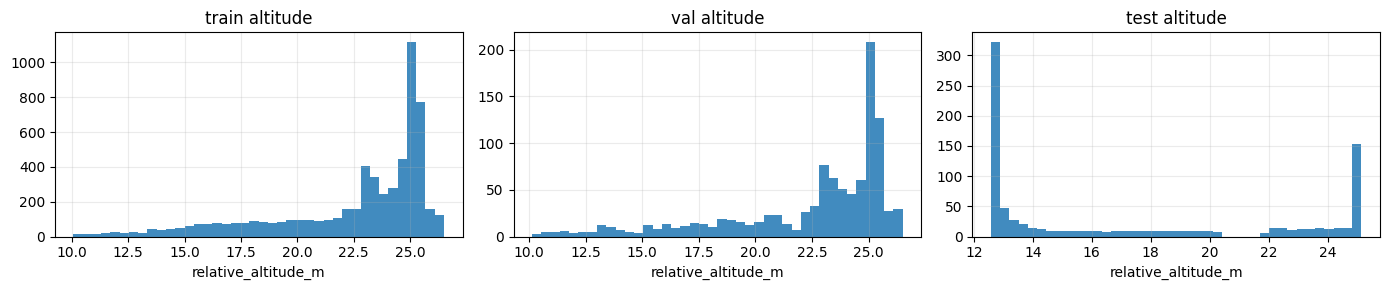

In [4]:
# Basic data sanity
def describe_targets(df, name):
    desc = df[target_cols].agg(['mean', 'std', 'min', 'max']).T
    desc.insert(0, 'split', name)
    return desc.reset_index().rename(columns={'index': 'target'})

display(pd.concat([
    describe_targets(train_df, 'train'),
    describe_targets(val_df, 'val'),
    describe_targets(test_df, 'test'),
], ignore_index=True))

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, df, title in zip(axes, [train_df, val_df, test_df], ['train', 'val', 'test']):
    ax.hist(df['x_relative_altitude_m'], bins=40, alpha=0.85)
    ax.set_title(f'{title} altitude')
    ax.set_xlabel('relative_altitude_m')
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [5]:
# Scaling and dataloaders
class StandardScaler:
    def __init__(self, mean, std):
        self.mean = np.asarray(mean, dtype=np.float32)
        self.std = np.asarray(std, dtype=np.float32)
        self.std = np.where(self.std < 1e-8, 1.0, self.std)

    @classmethod
    def fit(cls, arr):
        return cls(np.nanmean(arr, axis=0), np.nanstd(arr, axis=0))

    def transform(self, arr):
        return (np.asarray(arr, dtype=np.float32) - self.mean) / self.std

    def inverse_transform(self, arr):
        return np.asarray(arr, dtype=np.float32) * self.std + self.mean

    def to_dict(self, columns):
        return {'columns': list(columns), 'mean': self.mean.tolist(), 'std': self.std.tolist()}

X_train_raw = train_df[feature_cols].to_numpy(np.float32)
Y_train_raw = train_df[target_cols].to_numpy(np.float32)
X_val_raw = val_df[feature_cols].to_numpy(np.float32)
Y_val_raw = val_df[target_cols].to_numpy(np.float32)
X_test_raw = test_df[feature_cols].to_numpy(np.float32)
Y_test_raw = test_df[target_cols].to_numpy(np.float32)

x_scaler = StandardScaler.fit(X_train_raw)
y_scaler = StandardScaler.fit(Y_train_raw)

X_train = x_scaler.transform(X_train_raw)
Y_train = y_scaler.transform(Y_train_raw)
X_val = x_scaler.transform(X_val_raw)
Y_val = y_scaler.transform(Y_val_raw)
X_test = x_scaler.transform(X_test_raw)
Y_test = y_scaler.transform(Y_test_raw)

BATCH_SIZE = 1024
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(Y_train)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=False
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(Y_val)),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

x_mean_t = torch.tensor(x_scaler.mean, dtype=torch.float32, device=device)
x_std_t = torch.tensor(x_scaler.std, dtype=torch.float32, device=device)
y_mean_t = torch.tensor(y_scaler.mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_scaler.std, dtype=torch.float32, device=device)
feature_index = {c: i for i, c in enumerate(feature_cols)}
target_index = {c: i for i, c in enumerate(target_cols)}
print('batches:', len(train_loader), len(val_loader))


batches: 6 2


In [6]:
# Model
class RateDynamicsMLP(nn.Module):
    def __init__(self, n_in, n_out, hidden=512, depth=5, dropout=0.02):
        super().__init__()
        layers = []
        last = n_in
        for _ in range(depth):
            layers += [nn.Linear(last, hidden), nn.SiLU(), nn.LayerNorm(hidden)]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            last = hidden
        layers.append(nn.Linear(last, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

MODEL_CONFIG = dict(hidden=512, depth=5, dropout=0.02)
model = RateDynamicsMLP(len(feature_cols), len(target_cols), **MODEL_CONFIG).to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


RateDynamicsMLP(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=512, bias=True)
    (1): SiLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.02, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): SiLU()
    (14): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.02, inplace=False)
    (16): Linear(in_features=512, out_features=512, bias=True)
    (17): SiLU()
    (18): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.02, inplace=False)
    (20): Linear(in_features=512, out_features=1

epoch=001 train=1.03493 val=0.31918 val_data=0.29878 alt=0.063 rp=0.003 yaw=0.035 best_data=0.29878@1 lr=1.00e-03
epoch=020 train=0.09878 val=0.11126 val_data=0.10917 alt=0.004 rp=0.000 yaw=0.007 best_data=0.10917@20 lr=9.99e-04
epoch=040 train=0.08824 val=0.10615 val_data=0.10398 alt=0.005 rp=0.000 yaw=0.005 best_data=0.10153@39 lr=9.95e-04
epoch=060 train=0.08375 val=0.10036 val_data=0.09852 alt=0.005 rp=0.000 yaw=0.004 best_data=0.09758@53 lr=9.88e-04
epoch=080 train=0.07953 val=0.09789 val_data=0.09602 alt=0.005 rp=0.000 yaw=0.005 best_data=0.09435@77 lr=9.79e-04
epoch=100 train=0.07747 val=0.09669 val_data=0.09471 alt=0.005 rp=0.000 yaw=0.005 best_data=0.09435@77 lr=9.67e-04
epoch=120 train=0.07689 val=0.09731 val_data=0.09511 alt=0.005 rp=0.000 yaw=0.006 best_data=0.09399@107 lr=9.52e-04
epoch=140 train=0.07511 val=0.09723 val_data=0.09494 alt=0.006 rp=0.000 yaw=0.005 best_data=0.09399@107 lr=9.35e-04
epoch=160 train=0.07432 val=0.09778 val_data=0.09568 alt=0.005 rp=0.000 yaw=0.0

,epoch,train_loss,val_loss,train_data,val_data,train_alt_phy,val_alt_phy,train_roll_pitch_phy,val_roll_pitch_phy,train_yaw_phy,val_yaw_phy,lr
307,308,0.067399,0.098255,0.065538,0.095901,0.005685,0.006416,0.000187,0.000227,0.003331,0.005161,0.000712
308,309,0.067022,0.097956,0.065091,0.095671,0.005607,0.006116,0.000187,0.000228,0.003811,0.005145,0.000711
309,310,0.067124,0.098442,0.065308,0.096207,0.005502,0.005766,0.000190,0.000250,0.003301,0.005286,0.000709
310,311,0.067452,0.097403,0.065501,0.095243,0.005709,0.005512,0.000180,0.000248,0.003799,0.005179,0.000707
311,312,0.067270,0.098031,0.065411,0.095867,0.005679,0.005398,0.000189,0.000246,0.003325,0.005340,0.000706


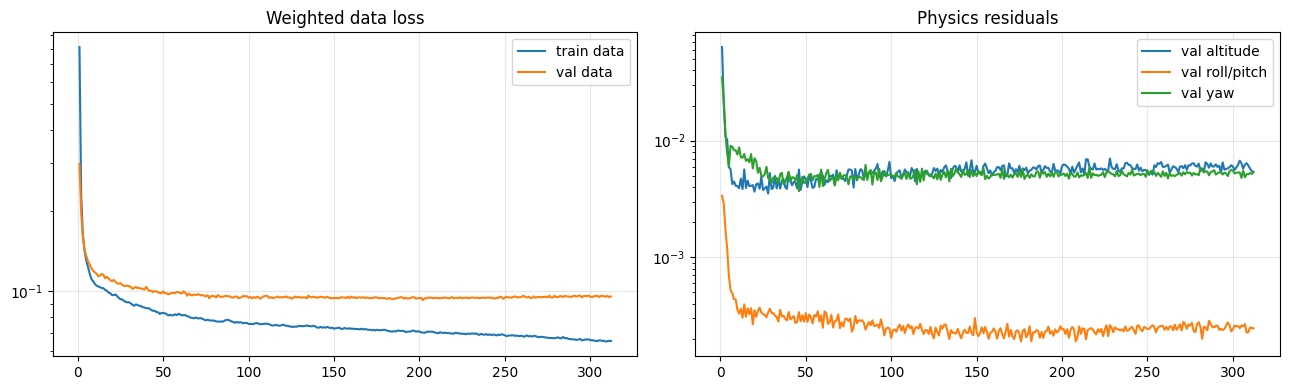

In [7]:
# Training with stronger altitude/yaw physics-informed loss
EPOCHS = 850
LR = 1.0e-3
WEIGHT_DECAY = 2e-5
PATIENCE = 110
GRAD_CLIP = 2.0

DATA_WEIGHT = 1.0
ALT_KIN_WEIGHT = 0.22
ROLL_PITCH_KIN_WEIGHT = 0.06
YAW_KIN_WEIGHT = 0.18
ALT_RESID_SCALE_M = 0.05
ROLL_PITCH_RESID_SCALE_RAD = np.deg2rad(0.7)
YAW_RESID_SCALE_RAD = np.deg2rad(0.45)

# Weighted target data fit. These are still one-step data terms, not physics.
TARGET_DATA_WEIGHTS = {
    'dx_relative_altitude_m': 2.2,
    'dx_vel_down_m_s': 1.5,
    'dx_yaw_deg': 2.0,
    'dx_yaw_rate_rad_s': 1.4,
}

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

target_weight_vec = torch.ones(len(target_cols), dtype=torch.float32, device=device)
for name, value in TARGET_DATA_WEIGHTS.items():
    if name in target_index:
        target_weight_vec[target_index[name]] = float(value)

def smooth_l1_weighted(pred, target, beta=0.5):
    err = pred - target
    abs_err = torch.abs(err)
    loss = torch.where(abs_err < beta, 0.5 * err ** 2 / beta, abs_err - 0.5 * beta)
    return torch.mean(loss * target_weight_vec[None, :])

def wrap_angle_rad(angle):
    return torch.atan2(torch.sin(angle), torch.cos(angle))

def raw_feature(xb_scaled, name):
    idx = feature_index[name]
    return xb_scaled[:, idx] * x_std_t[idx] + x_mean_t[idx]

def raw_pred_dx(pred_scaled, target_name):
    idx = target_index[target_name]
    return pred_scaled[:, idx] * y_std_t[idx] + y_mean_t[idx]

def physics_loss(xb_scaled, pred_scaled):
    dt = raw_feature(xb_scaled, 'dt_s').clamp_min(1e-4)

    # Altitude kinematics. PX4 NED vertical velocity is positive down, while
    # relative_altitude_m increases upward, so h_dot ~= -vel_down.
    vel_down = raw_feature(xb_scaled, 'x_vel_down_m_s')
    d_vel_down = raw_pred_dx(pred_scaled, 'dx_vel_down_m_s')
    vel_down_next = vel_down + d_vel_down
    expected_dh = -0.5 * (vel_down + vel_down_next) * dt
    pred_dh = raw_pred_dx(pred_scaled, 'dx_relative_altitude_m')
    alt_resid = (pred_dh - expected_dh) / ALT_RESID_SCALE_M
    alt_loss = torch.mean(alt_resid ** 2)

    # Euler kinematics from body rates. State angles are degrees, rates are rad/s.
    phi = torch.deg2rad(raw_feature(xb_scaled, 'x_roll_deg'))
    theta = torch.deg2rad(raw_feature(xb_scaled, 'x_pitch_deg')).clamp(-1.2, 1.2)
    p = raw_feature(xb_scaled, 'x_roll_rate_rad_s')
    q = raw_feature(xb_scaled, 'x_pitch_rate_rad_s')
    r = raw_feature(xb_scaled, 'x_yaw_rate_rad_s')

    tan_theta = torch.tan(theta)
    cos_theta = torch.cos(theta).clamp_min(0.2)
    sin_phi = torch.sin(phi)
    cos_phi = torch.cos(phi)

    phi_dot = p + tan_theta * (q * sin_phi + r * cos_phi)
    theta_dot = q * cos_phi - r * sin_phi
    psi_dot = (q * sin_phi + r * cos_phi) / cos_theta

    pred_dphi = torch.deg2rad(raw_pred_dx(pred_scaled, 'dx_roll_deg'))
    pred_dtheta = torch.deg2rad(raw_pred_dx(pred_scaled, 'dx_pitch_deg'))
    pred_dpsi = torch.deg2rad(raw_pred_dx(pred_scaled, 'dx_yaw_deg'))

    roll_pitch_resid = torch.stack([
        (pred_dphi - phi_dot * dt) / ROLL_PITCH_RESID_SCALE_RAD,
        (pred_dtheta - theta_dot * dt) / ROLL_PITCH_RESID_SCALE_RAD,
    ], dim=1)
    roll_pitch_loss = torch.mean(roll_pitch_resid ** 2)

    yaw_resid = wrap_angle_rad(pred_dpsi - psi_dot * dt) / YAW_RESID_SCALE_RAD
    yaw_loss = torch.mean(yaw_resid ** 2)
    return alt_loss, roll_pitch_loss, yaw_loss

def run_epoch(loader, train_mode):
    model.train(train_mode)
    totals = {'loss': 0.0, 'data': 0.0, 'alt': 0.0, 'roll_pitch': 0.0, 'yaw': 0.0}
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if train_mode:
            optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        data_loss = smooth_l1_weighted(pred, yb)
        alt_loss, roll_pitch_loss, yaw_loss = physics_loss(xb, pred)
        loss = (
            DATA_WEIGHT * data_loss
            + ALT_KIN_WEIGHT * alt_loss
            + ROLL_PITCH_KIN_WEIGHT * roll_pitch_loss
            + YAW_KIN_WEIGHT * yaw_loss
        )
        if train_mode:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        batch_n = len(xb)
        totals['loss'] += float(loss.detach().cpu()) * batch_n
        totals['data'] += float(data_loss.detach().cpu()) * batch_n
        totals['alt'] += float(alt_loss.detach().cpu()) * batch_n
        totals['roll_pitch'] += float(roll_pitch_loss.detach().cpu()) * batch_n
        totals['yaw'] += float(yaw_loss.detach().cpu()) * batch_n
        n += batch_n
    return {k: v / max(n, 1) for k, v in totals.items()}

best_state = None
best_val = float('inf')
best_epoch = -1
history = []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    scheduler.step()
    row = {
        'epoch': epoch,
        'train_loss': tr['loss'], 'val_loss': va['loss'],
        'train_data': tr['data'], 'val_data': va['data'],
        'train_alt_phy': tr['alt'], 'val_alt_phy': va['alt'],
        'train_roll_pitch_phy': tr['roll_pitch'], 'val_roll_pitch_phy': va['roll_pitch'],
        'train_yaw_phy': tr['yaw'], 'val_yaw_phy': va['yaw'],
        'lr': scheduler.get_last_lr()[0],
    }
    history.append(row)
    # Early stopping monitors weighted data fit; physics losses are tracked but
    # not used alone to decide the best checkpoint.
    monitor = va['data']
    if monitor < best_val:
        best_val = monitor
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 20 == 0 or epoch == 1:
        print(
            f"epoch={epoch:03d} train={tr['loss']:.5f} val={va['loss']:.5f} "
            f"val_data={va['data']:.5f} alt={va['alt']:.3f} "
            f"rp={va['roll_pitch']:.3f} yaw={va['yaw']:.3f} "
            f"best_data={best_val:.5f}@{best_epoch} lr={scheduler.get_last_lr()[0]:.2e}"
        )
    if epoch - best_epoch >= PATIENCE:
        print(f'early stop at epoch={epoch}, best_epoch={best_epoch}')
        break

model.load_state_dict(best_state)
print('training seconds:', round(time.time() - t0, 1))
hist_df = pd.DataFrame(history)
display(hist_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_data'], label='train data')
axes[0].plot(hist_df['epoch'], hist_df['val_data'], label='val data')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_title('Weighted data loss')
axes[1].plot(hist_df['epoch'], hist_df['val_alt_phy'], label='val altitude')
axes[1].plot(hist_df['epoch'], hist_df['val_roll_pitch_phy'], label='val roll/pitch')
axes[1].plot(hist_df['epoch'], hist_df['val_yaw_phy'], label='val yaw')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_title('Physics residuals')
plt.tight_layout()
plt.show()


In [8]:
# One-step metrics in physical units
@torch.no_grad()
def predict_dx(df):
    x = x_scaler.transform(df[feature_cols].to_numpy(np.float32))
    preds = []
    model.eval()
    for i in range(0, len(x), 4096):
        xb = torch.tensor(x[i:i+4096], dtype=torch.float32, device=device)
        pred_scaled = model(xb).detach().cpu().numpy()
        preds.append(pred_scaled)
    pred_scaled = np.concatenate(preds, axis=0) if preds else np.zeros((0, len(target_cols)), dtype=np.float32)
    return y_scaler.inverse_transform(pred_scaled)

def one_step_metrics(df, split):
    pred = predict_dx(df)
    true = df[target_cols].to_numpy(np.float32)
    rows = []
    for j, col in enumerate(target_cols):
        err = pred[:, j] - true[:, j]
        rows.append({
            'split': split,
            'target': col,
            'rmse': float(np.sqrt(np.mean(err ** 2))),
            'mae': float(np.mean(np.abs(err))),
            'std_true': float(np.std(true[:, j])),
        })
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    one_step_metrics(train_df, 'train'),
    one_step_metrics(val_df, 'val'),
    one_step_metrics(test_df, 'test'),
], ignore_index=True)
display(metrics_df)


,split,target,rmse,mae,std_true
0,train,dx_relative_altitude_m,0.019891,0.003331,0.025177
1,train,dx_vel_north_m_s,0.004031,0.001439,0.006514
2,train,dx_vel_east_m_s,0.045526,0.002801,0.047572
3,train,dx_vel_down_m_s,0.006970,0.002228,0.007760
4,train,dx_roll_deg,0.005801,0.001379,0.040253
5,train,dx_pitch_deg,0.159783,0.003985,0.168031
6,train,dx_yaw_deg,0.080754,0.005705,0.112778
7,train,dx_roll_rate_rad_s,0.001065,0.000274,0.003625
8,train,dx_pitch_rate_rad_s,0.000868,0.000275,0.003638
9,train,dx_yaw_rate_rad_s,0.000357,0.000244,0.002668


In [9]:
# Rollout sanity by scenario
def make_feature_row(state_vec, action_vec, prev_action_vec, dt_s):
    row = []
    row.extend(state_vec.tolist())
    row.extend(action_vec.tolist())
    row.extend(prev_action_vec.tolist())
    row.extend((action_vec - prev_action_vec).tolist())
    row.append(float(dt_s))
    return np.asarray(row, dtype=np.float32)

@torch.no_grad()
def rollout_scenario(df, scenario, max_steps=None):
    sdf = df[df['scenario'].eq(scenario)].sort_values('time_s').reset_index(drop=True)
    if max_steps is not None:
        sdf = sdf.iloc[:max_steps].copy()
    if len(sdf) < 2:
        return None
    true_x = sdf[[f'x_{c}' for c in state_cols]].to_numpy(np.float32)
    true_next = sdf[[f'x_next_{c}' for c in state_cols]].to_numpy(np.float32)
    actions = sdf[[f'u_{c}' for c in action_cols]].to_numpy(np.float32)
    prev_actions_logged = sdf[[f'prev_u_{c}' for c in action_cols]].to_numpy(np.float32)
    dts = sdf['dt_s'].to_numpy(np.float32)

    x_pred = true_x[0].copy()
    prev_action = prev_actions_logged[0].copy()
    pred_states = []
    for k in range(len(sdf)):
        feat = make_feature_row(x_pred, actions[k], prev_action, dts[k])
        feat_scaled = x_scaler.transform(feat[None, :])
        dx_scaled = model(torch.tensor(feat_scaled, dtype=torch.float32, device=device)).cpu().numpy()
        dx = y_scaler.inverse_transform(dx_scaled)[0]
        x_pred = x_pred + dx
        pred_states.append(x_pred.copy())
        prev_action = actions[k].copy()
    pred_states = np.asarray(pred_states)
    err = pred_states - true_next
    rows = []
    for j, col in enumerate(state_cols):
        rows.append({
            'scenario': scenario,
            'state': col,
            'rollout_rmse': float(np.sqrt(np.mean(err[:, j] ** 2))),
            'rollout_max_abs': float(np.max(np.abs(err[:, j]))),
            'steps': int(len(sdf)),
        })
    return pd.DataFrame(rows), sdf, pred_states, true_next

scenario_metrics = []
for scenario in sorted(test_df['scenario'].unique()):
    result = rollout_scenario(test_df, scenario)
    if result is None:
        continue
    m, _, _, _ = result
    scenario_metrics.append(m)
rollout_metrics_df = pd.concat(scenario_metrics, ignore_index=True)
display(rollout_metrics_df)


,scenario,state,rollout_rmse,rollout_max_abs,steps
0,N11_mixed_sequence,relative_altitude_m,6.518639,9.623199,899
1,N11_mixed_sequence,vel_north_m_s,1.717955,2.388802,899
2,N11_mixed_sequence,vel_east_m_s,1.968041,2.993908,899
3,N11_mixed_sequence,vel_down_m_s,0.329254,0.509566,899
4,N11_mixed_sequence,roll_deg,1.043553,1.414044,899
5,N11_mixed_sequence,pitch_deg,0.790782,2.782496,899
6,N11_mixed_sequence,yaw_deg,6.359255,8.258888,899
7,N11_mixed_sequence,roll_rate_rad_s,0.004909,0.059032,899
8,N11_mixed_sequence,pitch_rate_rad_s,0.005928,0.043851,899
9,N11_mixed_sequence,yaw_rate_rad_s,0.009709,0.062855,899


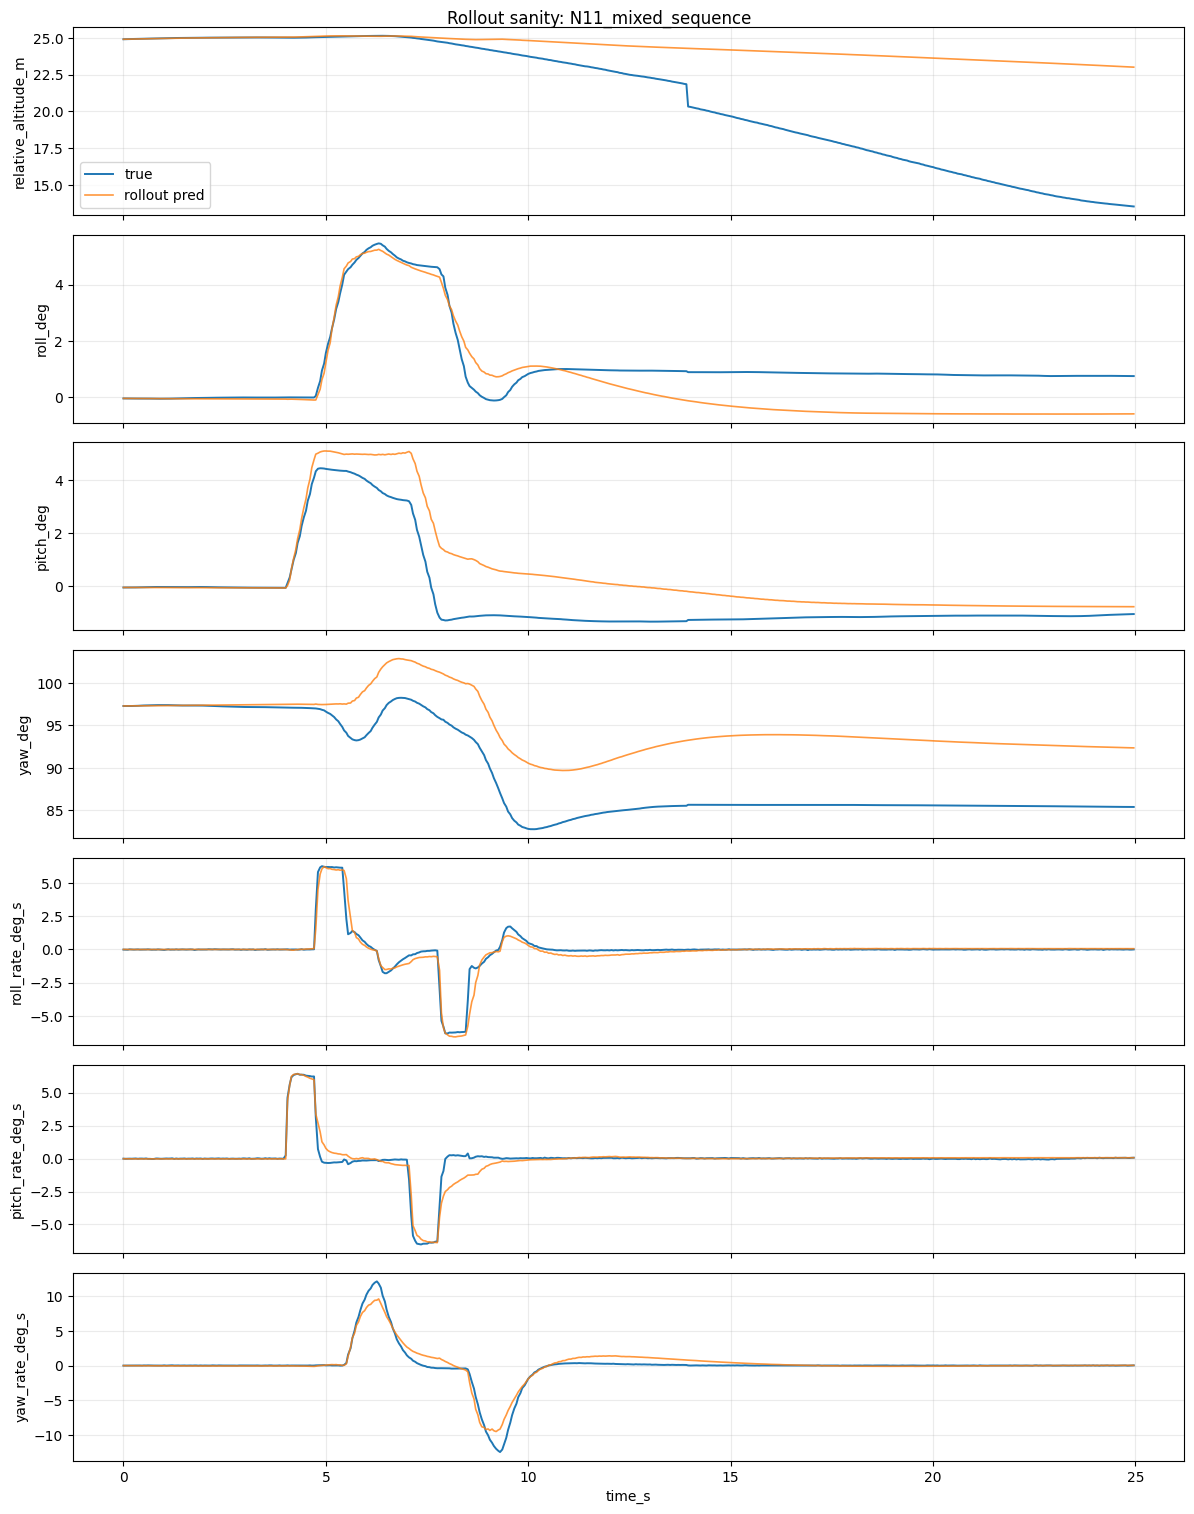

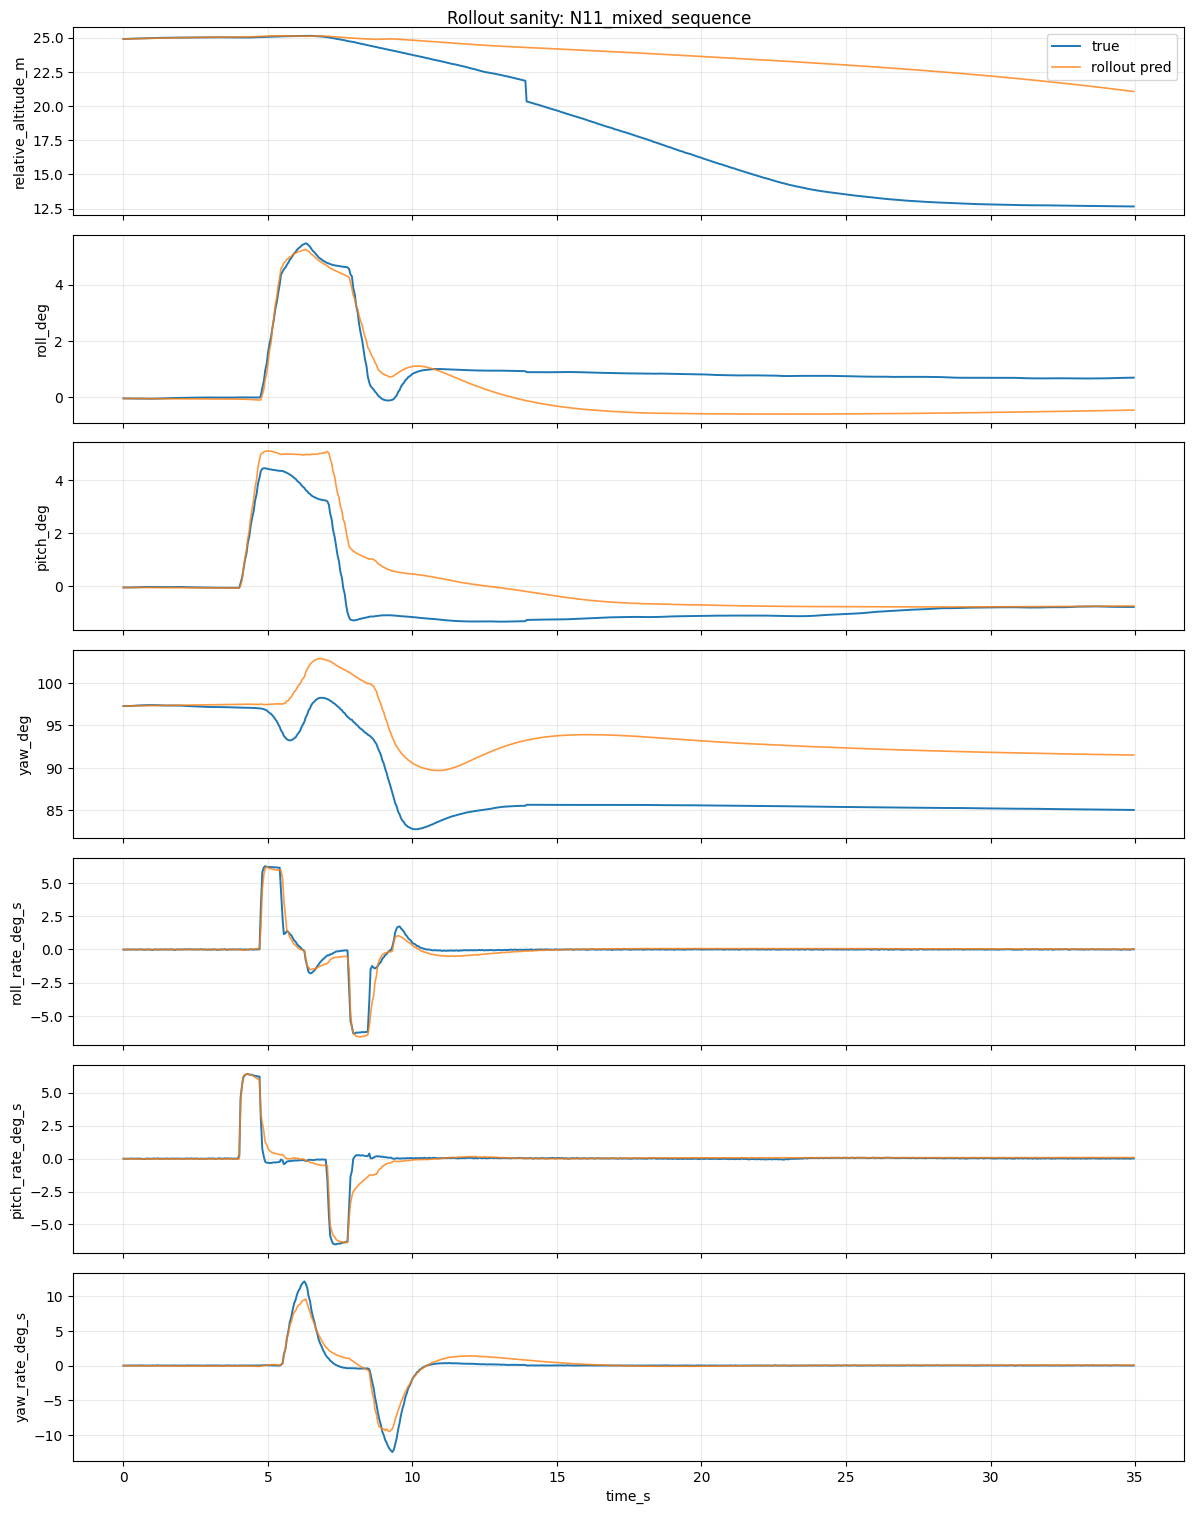

In [10]:
# Plot selected rollout scenarios
def plot_rollout(df, scenario, max_steps=500):
    result = rollout_scenario(df, scenario, max_steps=max_steps)
    if result is None:
        print('not enough rows for', scenario)
        return
    _, sdf, pred_states, true_next = result
    t = sdf['time_s'].to_numpy()
    plot_states = ['relative_altitude_m', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
    n = len(plot_states)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.2 * n), sharex=True)
    for ax, state in zip(axes, plot_states):
        if state not in state_cols:
            continue
        j = state_cols.index(state)
        y_true = true_next[:, j]
        y_pred = pred_states[:, j]
        if state.endswith('_rad_s'):
            y_true = np.rad2deg(y_true)
            y_pred = np.rad2deg(y_pred)
            label = state.replace('_rad_s', '_deg_s')
        else:
            label = state
        ax.plot(t, y_true, label='true', lw=1.4)
        ax.plot(t, y_pred, label='rollout pred', lw=1.2, alpha=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.25)
    axes[0].legend(loc='best')
    axes[-1].set_xlabel('time_s')
    fig.suptitle(f'Rollout sanity: {scenario}')
    plt.tight_layout()
    plt.show()

for scenario in sorted(test_df['scenario'].unique())[:4]:
    plot_rollout(test_df, scenario, max_steps=500)

if 'N11_mixed_sequence' in set(test_df['scenario']):
    plot_rollout(test_df, 'N11_mixed_sequence', max_steps=700)


In [11]:
# Save checkpoint for future MPC experiments
SAVE_ROOT = Path('/content/drive/MyDrive/PX4_Phase1_Models') if IN_COLAB else DATASET_PATH / 'models'
SAVE_ROOT.mkdir(parents=True, exist_ok=True)
stamp = time.strftime('%Y%m%d_%H%M%S')
ckpt_path = SAVE_ROOT / f'px4_phase1_rate_dynamics_mlp_v4_alt_yaw_physics_{stamp}.pt'

checkpoint = {
    'model_version': 'px4_phase1_rate_dynamics_mlp_v4_alt_yaw_physics',
    'state_dict': model.state_dict(),
    'model_config': {
        'n_in': len(feature_cols),
        'n_out': len(target_cols),
        **MODEL_CONFIG,
    },
    'loss_config': {
        'data_weight': DATA_WEIGHT,
        'alt_kin_weight': ALT_KIN_WEIGHT,
        'roll_pitch_kin_weight': ROLL_PITCH_KIN_WEIGHT,
        'yaw_kin_weight': YAW_KIN_WEIGHT,
        'target_data_weights': TARGET_DATA_WEIGHTS,
        'alt_resid_scale_m': ALT_RESID_SCALE_M,
        'roll_pitch_resid_scale_rad': float(ROLL_PITCH_RESID_SCALE_RAD),
        'yaw_resid_scale_rad': float(YAW_RESID_SCALE_RAD),
        'validation_policy': 'nominal_pool_random_validation_with_N11_mixed_test',
    },
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'state_cols': state_cols,
    'action_cols': action_cols,
    'x_scaler': x_scaler.to_dict(feature_cols),
    'y_scaler': y_scaler.to_dict(target_cols),
    'dataset_path': str(DATASET_PATH),
    'metadata': metadata,
    'history': hist_df.to_dict(orient='records'),
    'one_step_metrics': metrics_df.to_dict(orient='records'),
    'rollout_metrics': rollout_metrics_df.to_dict(orient='records'),
}
torch.save(checkpoint, ckpt_path)
print('saved:', ckpt_path)


saved: /content/drive/MyDrive/PX4_Phase1_Models/px4_phase1_rate_dynamics_mlp_v4_alt_yaw_physics_20260506_102148.pt


In [12]:
# Minimal load check
loaded = torch.load(ckpt_path, map_location='cpu')
print('loaded keys:', sorted(loaded.keys()))
print('feature count:', len(loaded['feature_cols']))
print('target count:', len(loaded['target_cols']))


loaded keys: ['action_cols', 'dataset_path', 'feature_cols', 'history', 'loss_config', 'metadata', 'model_config', 'model_version', 'one_step_metrics', 'rollout_metrics', 'state_cols', 'state_dict', 'target_cols', 'x_scaler', 'y_scaler']
feature count: 23
target count: 10
